#  Retail Store Sales – Exploratory Data Analysis

**Dataset:** 12,575 transactions · 11 columns · 1 Jan 2022 – 18 Jan 2025

**Contents**
1. Setup & Data Loading
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Outlier Detection & Treatment
6. Univariate Analysis
7. Time-Based Analysis
8. Category Analysis
9. Key Findings & Recommendations



## 1. Setup & Data Loading

In [ ]:
#importing major libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#reading the csv
df=pd.read_csv('/content/retail_store_sales.csv')

## 2. Data Understanding

### First Look at the Data

In [ ]:
#inspecting the first few records
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
#inspecting the shape of dataset
print(f'This dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

This dataset contains 12575 rows and 11 columns.


In [ ]:
#checking basic structure and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Category          12575 non-null  str    
 3   Item              11362 non-null  str    
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  str    
 8   Location          12575 non-null  str    
 9   Transaction Date  12575 non-null  str    
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(1), str(7)
memory usage: 1.1+ MB


**Insights**
- The data has **12,575 transactions and 11 columns**: IDs, category/item, price, quantity, total, payment method, location, date and discount flag.
- `Transaction Date` is stored as text (`object`) and must be converted to a date type.
- `Item`, `Price Per Unit`, `Quantity`, `Total Spent` and `Discount Applied` have fewer non-null values than the other columns, so they contain missing data.

### Duplicates & Missing Values

In [ ]:
#checking if there are any duplicate records
print(f'This dataset contains {df.duplicated().sum()} duplicate records.')

This dataset contains 0 duplicate records.


In [ ]:
#inspecting missing records in a dataset
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

**Insights**
- **No duplicate records**, so every row is a unique transaction.
- Missing values: `Item` 1,213 (9.6%) · `Price Per Unit` 609 · `Quantity` 604 · `Total Spent` 604 · `Discount Applied` 4,199 (33%).
- The missing values are not random: the 609 missing prices and the 604 missing quantities/totals each occur in rows where `Item` is *also* missing. This helps us repair them accurately (see 3.1).

###  Unique Values

In [ ]:
#inspecting unique values for each column except transaction id, customer id and transaction date
df_cols=set(df.columns)
exclude ={'Transaction ID','Customer ID','Transaction Date'}
df_cols=df_cols.difference(exclude)
for col in df_cols:
  print(col)
  print(df[col].unique())

Category
<StringArray>
[                        'Patisserie',                      'Milk Products',
                           'Butchers',                          'Beverages',
                               'Food',                          'Furniture',
      'Electric household essentials', 'Computers and electric accessories']
Length: 8, dtype: str
Quantity
[10.  9.  2.  7.  8. nan  1.  3.  6.  4.  5.]
Location
<StringArray>
['Online', 'In-store']
Length: 2, dtype: str
Price Per Unit
[18.5 29.  21.5 27.5 12.5  nan  5.  33.5 36.5  8.   6.5 39.5 24.5 23.
 35.  14.   9.5 41.  20.  38.  15.5 11.  32.  26.  30.5 17. ]
Payment Method
<StringArray>
['Digital Wallet', 'Credit Card', 'Cash']
Length: 3, dtype: str
Total Spent
[185.  261.   43.  247.5  87.5 200.   40.    nan  27.5 109.5  72.   52.
  45.5 237.   55.  232.  275.   23.  126.  105.   66.5  18.5  49.  134.
 410.  245.  182.5 100.  196.  315.  287.   76.   92.5 190.  255.5 276.5
  46.5   8.  107.5 165.   80.  192.5 335.   66.  215.  

**Insights**
- 8 categories, 3 payment methods (Cash, Credit Card, Digital Wallet) and 2 locations (Online, In-store).
- `Discount Applied` has three states: `True`, `False` and `NaN` (unknown).
- Item names end with a **category code** (e.g. `Item_10_PAT` = Patisserie, `_BEV` = Beverages), which tells us each item belongs to exactly one category.

## 3. Data Cleaning

Before filling anything with a mean or mode, we test whether the data follows hidden rules.

In [ ]:
#checking hidden rules in the data
known = df.dropna(subset=['Item','Price Per Unit'])
chk = df.dropna(subset=['Price Per Unit','Quantity','Total Spent'])
print('Rows where Total Spent != Price x Quantity      :', (abs(chk['Total Spent']-chk['Price Per Unit']*chk['Quantity'])>0.01).sum())
print('Items having more than one price                :', (known.groupby('Item')['Price Per Unit'].nunique()>1).sum())
print('(Category, Price) pairs that match >1 item      :', (known.groupby(['Category','Price Per Unit'])['Item'].nunique()>1).sum())

Rows where Total Spent != Price x Quantity      : 0
Items having more than one price                : 0
(Category, Price) pairs that match >1 item      : 0


**Insights**
- `Total Spent = Price Per Unit × Quantity` holds in **every** complete row.
- **Each item has exactly one price**, and a *(Category, Price)* pair points to exactly one item.
- Therefore a missing price can be recovered from `Total ÷ Quantity`, and a missing item from `Category + Price` – no guessing needed.

###  Price Per Unit & Item

In [ ]:
#recovering missing price per unit from total spent / quantity
df['Price Per Unit']=df['Price Per Unit'].fillna(df['Total Spent']/df['Quantity'])

In [ ]:
#filling item column using category + price
known = df.dropna(subset=['Item','Price Per Unit'])
lookup = known.drop_duplicates(['Category','Price Per Unit']).set_index(['Category','Price Per Unit'])['Item']
keys = pd.MultiIndex.from_frame(df[['Category','Price Per Unit']])
df['Item'] = df['Item'].fillna(pd.Series(lookup.reindex(keys).values, index=df.index))

In [ ]:
#checking distinct prices for each item category
df.groupby('Item')['Price Per Unit'].value_counts()

Item          Price Per Unit
Item_10_BEV   18.5              23
Item_10_BUT   18.5              16
Item_10_CEA   18.5              79
Item_10_EHE   18.5              45
Item_10_FOOD  18.5              60
                                ..
Item_9_EHE    17.0              63
Item_9_FOOD   17.0              78
Item_9_FUR    17.0              16
Item_9_MILK   17.0              11
Item_9_PAT    17.0              59
Name: count, Length: 200, dtype: int64

In [ ]:
#filling missing price per unit with most frequent mode for each item category
df['Price Per Unit']=df.groupby('Item')['Price Per Unit'].transform(lambda x: x.fillna(x.mode()[0]))

**Insights**
- All **1,213 missing items and 609 missing prices were recovered exactly** from the data's own rules.
- Every item now shows a single price, confirming the repair is consistent. The last cell is kept from the original – it is now a safety net that changes nothing.

### Quantity & Total Spent

In [ ]:
#filling quantity column with median values
df['Qty_imputed']=df['Quantity'].isna()
df['Quantity']=df['Quantity'].fillna(df['Quantity'].median())

In [ ]:
#filling total spent with price*quantity
df['Total Spent']=df['Quantity']*df['Price Per Unit']

### Discount Applied

In [ ]:
#mapping true with yes, false with no and nan with unknown
df['Discount Applied']=df['Discount Applied'].map({True: 'Yes',False: 'No'}).fillna('Unknown')

**Insights**
- Only the **604 rows (4.8%)** with both Quantity and Total Spent missing needed an estimate – everything else was calculated exactly.
- Missing discount status (33%) is kept as its own `Unknown` group instead of guessing Yes/No.

### Final Check & Data Types

In [ ]:
#rechecking null values in the dataframe
df.isna().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Qty_imputed         0
dtype: int64

In [ ]:
#changing datatypes
df['Quantity']=df['Quantity'].astype('int64')
df['Transaction Date']=pd.to_datetime(df['Transaction Date'])

In [ ]:
#rechecking datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  str           
 1   Customer ID       12575 non-null  str           
 2   Category          12575 non-null  str           
 3   Item              12575 non-null  str           
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  int64         
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  str           
 8   Location          12575 non-null  str           
 9   Transaction Date  12575 non-null  datetime64[us]
 10  Discount Applied  12575 non-null  str           
 11  Qty_imputed       12575 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(2), int64(1), str(7)
memory usage: 1.1 MB


**Insights**
- **No missing values remain** and all columns now have suitable types (`Quantity` as integer, `Transaction Date` as datetime).

## 4. Feature Engineering

In [ ]:
#Date Features
df['Year'] = df['Transaction Date'].dt.year
df['Quarter'] = df['Transaction Date'].dt.quarter
df['Month'] = df['Transaction Date'].dt.month
df['Month_name'] = df['Transaction Date'].dt.month_name()
df['Day_of_week'] = df['Transaction Date'].dt.day_name()
df['is_weekend'] = df['Transaction Date'].dt.dayofweek >= 5
df['Year_month'] = df['Transaction Date'].dt.to_period('M').dt.to_timestamp()
print(df['Transaction Date'].min().date(), 'to', df['Transaction Date'].max().date())
df.dtypes

2022-01-01 to 2025-01-18


Transaction ID                 str
Customer ID                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                     int64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied               str
Qty_imputed                   bool
Year                         int32
Quarter                      int32
Month                        int32
Month_name                     str
Day_of_week                    str
is_weekend                    bool
Year_month          datetime64[us]
dtype: object

**Insights**
- The data covers **1 Jan 2022 to 18 Jan 2025**.
- ⚠️ Because it ends on the 18th, **January 2025 is a partial month**. It is excluded from the monthly trend and month × year heatmap below, otherwise it looks like a false "revenue crash".

In [ ]:
#setting color palette
sns.set_palette('Blues_d')

## 5. Outlier Detection & Treatment

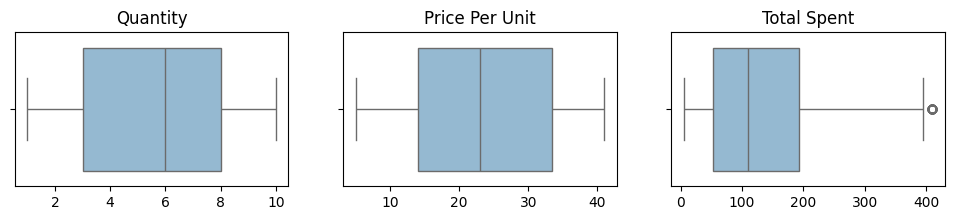

In [ ]:
#outlier detection using boxplots
fig,axs=plt.subplots(nrows=1,ncols=3,figsize=(12,2))
sns.boxplot(data=df,x='Quantity',ax =axs[0])
axs[0].set_title('Quantity')
axs[0].set_xlabel('')
sns.boxplot(data=df,x='Price Per Unit',ax =axs[1])
axs[1].set_title('Price Per Unit')
axs[1].set_xlabel('')
sns.boxplot(data=df,x='Total Spent',ax =axs[2])
axs[2].set_title('Total Spent')
axs[2].set_xlabel('')
plt.show()

In [ ]:
#outliers treatment
cols=['Quantity','Price Per Unit','Total Spent']
for col in cols:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-(1.5*iqr)
  upper_bound=q3+(1.5*iqr)
  df[col]=np.where(df[col]>upper_bound,upper_bound,df[col])
  df[col]=np.where(df[col]<lower_bound,lower_bound,df[col])

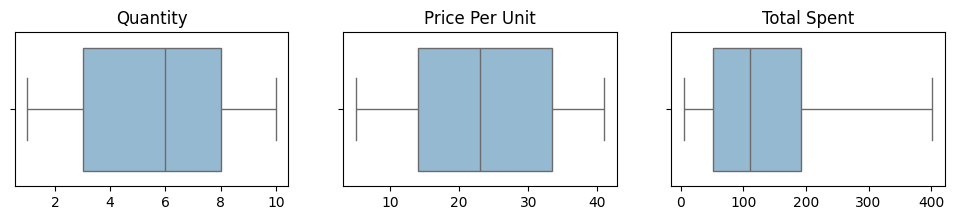

In [ ]:
fig,axs=plt.subplots(nrows=1,ncols=3,figsize=(12,2))
sns.boxplot(data=df,x='Quantity',ax =axs[0])
axs[0].set_title('Quantity')
axs[0].set_xlabel('')
sns.boxplot(data=df,x='Price Per Unit',ax =axs[1])
axs[1].set_title('Price Per Unit')
axs[1].set_xlabel('')
sns.boxplot(data=df,x='Total Spent',ax =axs[2])
axs[2].set_title('Total Spent')
axs[2].set_xlabel('')
plt.show()

**Insights**
- `Quantity` (1–10) and `Price Per Unit` (5–41) have **no outliers** – they sit in fixed business ranges.
- `Total Spent` has **60 baskets (0.5%) between about 403 and 410** flagged by the IQR rule. These are **valid values** (the largest possible basket is 41 × 10 = 410), so capping them at ≈ 402 changes total revenue by only about 0.03%.
- The boxplots before and after look almost identical, which confirms the data is clean.

## 6. Univariate Analysis

### Price Per Unit

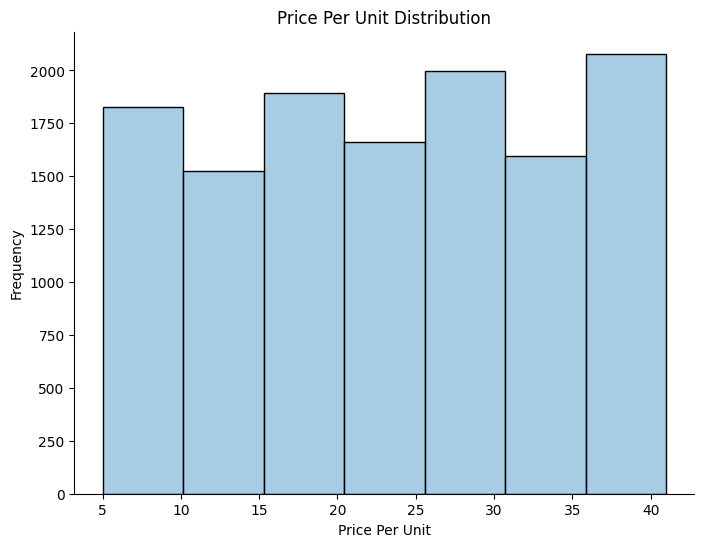

In [ ]:
#price per unit distribution
plt.figure(figsize=(8,6))
sns.histplot(data=df,x='Price Per Unit',binwidth=5)
plt.title('Price Per Unit Distribution')
plt.xlabel('Price Per Unit')
plt.ylabel('Frequency')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- Prices are spread **fairly evenly from 5 to 41** with no dominant price band. The store sells a balanced mix of cheap, mid-range and premium items.

### Total Spent

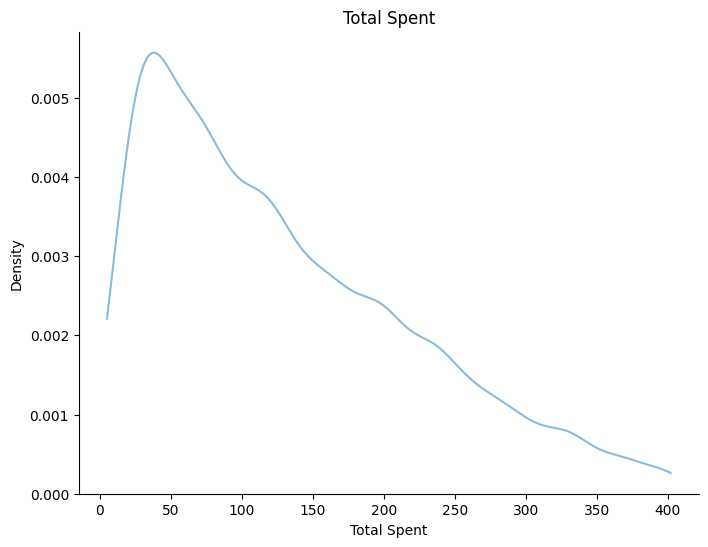

In [ ]:
#total spent
plt.figure(figsize=(8,6))
sns.kdeplot(data=df,x='Total Spent',cut=0)
plt.title('Total Spent')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- The distribution is **right-skewed**: most transactions are small, with a long tail of larger baskets up to about 400.
- The **median (≈ 110)** is lower than the mean (≈ 130), so the median describes a "typical" transaction better.

### 6.3 Category Distribution

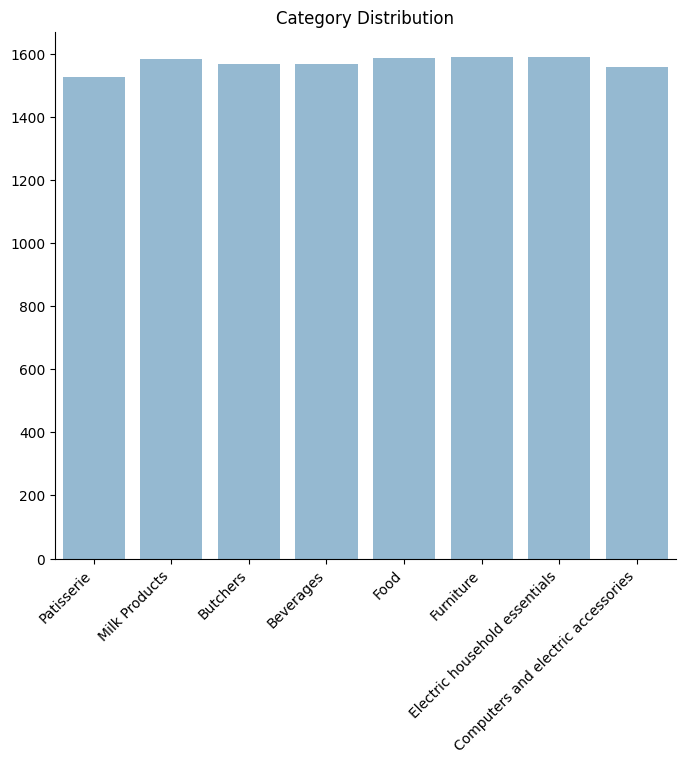

In [ ]:
#category distribution
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='Category')
plt.tight_layout()
plt.title('Category Distribution')
plt.xlabel('')
plt.ylabel('')
plt.gca().spines[['top','right']].set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.show()

**Insights**
- All 8 categories have **almost the same number of transactions (about 1,530–1,590 each)**. No category wins on footfall, so differences in revenue come from *basket value*, not popularity.

## 7. Time-Based Analysis

### Monthly Revenue

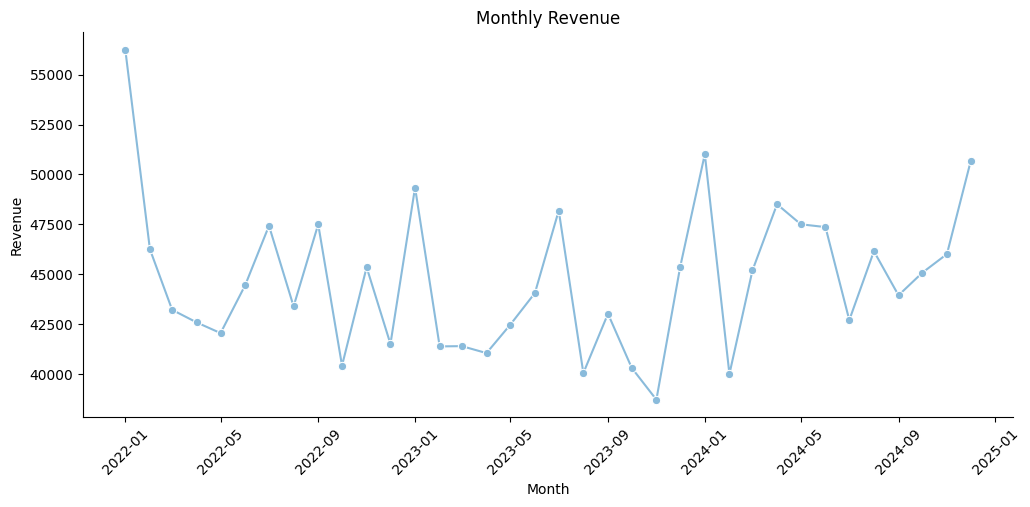

In [ ]:
#monthly revenue
monthly = df[df['Year_month'] < '2025-01-01'].groupby('Year_month')['Total Spent'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Year_month', y='Total Spent', marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- Monthly revenue stays in a stable band of roughly **38k–56k** with **no strong long-term trend**.
- **January is the peak in every year**, and Jan 2022 is the highest month on record.
- The sharp fall seen in the original chart was **not real**: the data stops on 18 Jan 2025. Scaled to a full month, Jan 2025 would be about 46k, in line with earlier Januaries.

### Yearly Revenue

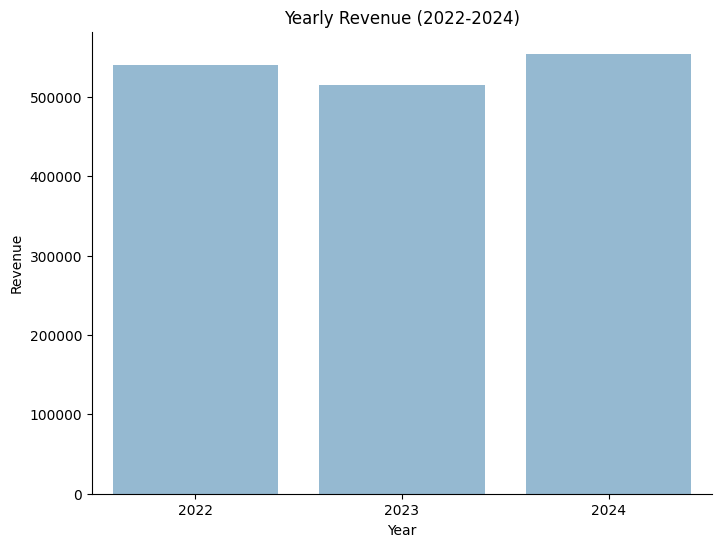

In [ ]:
#yearly revenue
yearly = df[df['Year'] < 2025].groupby('Year')['Total Spent'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=yearly, x='Year', y='Total Spent')
plt.title('Yearly Revenue (2022-2024)')
plt.xlabel('Year')
plt.ylabel('Revenue')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- Revenue went **2022 ≈ 540k → 2023 ≈ 515k (about −4.6%) → 2024 ≈ 554k (about +7.5%)**. 2024 is the best year, recovering from a dip in 2023.
- Changes follow the **number of transactions** (4,134 → 3,987 → 4,241), not basket size, which stays near 130 each year. Growth here is driven by customer traffic, not higher prices.

### Revenue by Day of Week

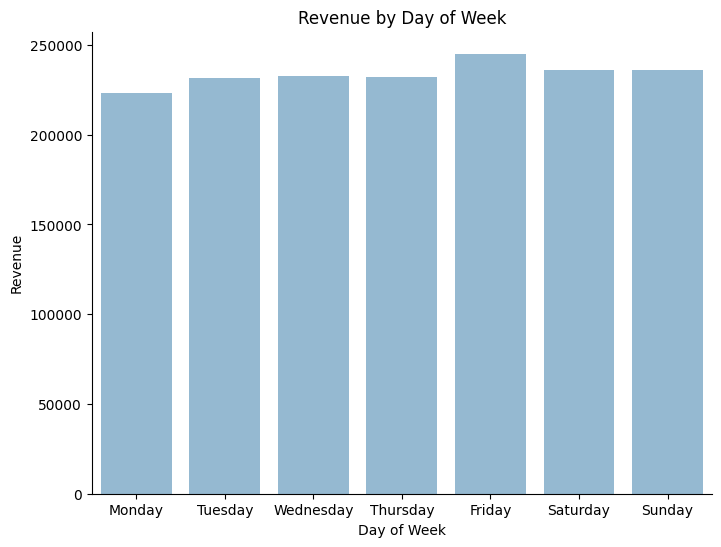

In [ ]:
#revenue by day of week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('Day_of_week')['Total Spent'].sum().reindex(dow_order).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=dow, x='Day_of_week', y='Total Spent')
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- **Friday is the strongest day (≈ 245k)** and **Monday the weakest (≈ 223k)** – a gap of about 10%.
- The other days are close together (≈ 230–236k). Weekends are *not* special: they hold about 29% of transactions, almost exactly their 2-in-7 share of days.

### Revenue by Month and Year

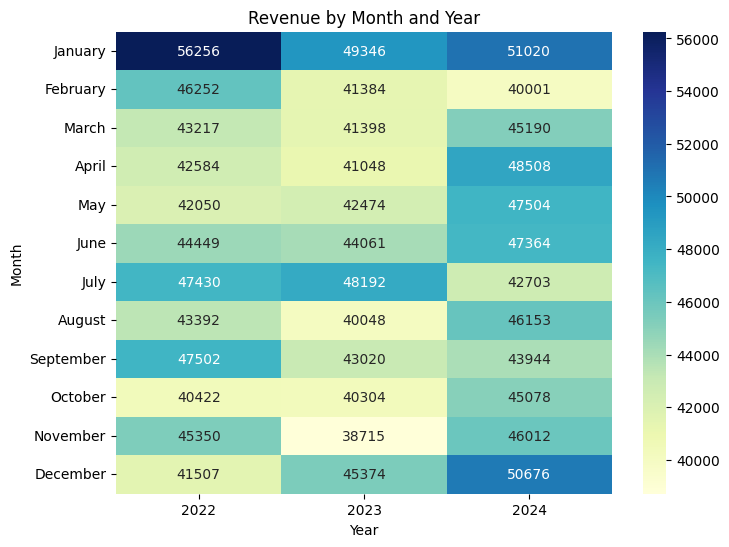

In [ ]:
#visualising revenue by month and year through heatmap
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
pt = df[df['Year'] < 2025].pivot_table(index='Month_name', columns='Year', values='Total Spent', aggfunc='sum').reindex(month_order)

plt.figure(figsize=(8,6))
sns.heatmap(data=pt, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Revenue by Month and Year')
plt.xlabel('Year')
plt.ylabel('Month')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

**Insights**
- **January is the strongest month in all three years** (≈ 56k, 49k and 51k) – the only month that is consistently on top.
- Over the three years combined, **October and February are the weakest months**, with July and December next-best after January.
- Apart from January, the pattern is **not very stable year to year**: July was strong in 2022–23 but weaker in 2024, while October and December were much stronger in 2024. Treat month-level differences other than January with caution.

## 8. Category Analysis

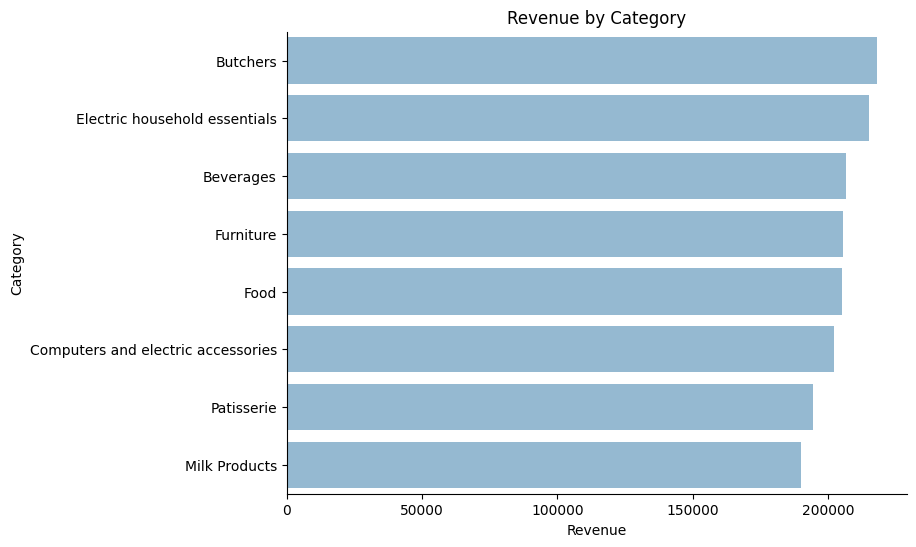

In [ ]:
#revenue by category
cat_rev = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=cat_rev, y='Category', x='Total Spent')
plt.title('Revenue by Category')
plt.xlabel('Revenue')
plt.ylabel('Category')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

In [ ]:
#revenue share by category
cat_rev['Share_%'] = (cat_rev['Total Spent'] / cat_rev['Total Spent'].sum() * 100).round(1)
cat_rev

,Category,Total Spent,Share_%
0,Butchers,218065.0,13.3
1,Electric household essentials,215217.5,13.1
2,Beverages,206766.5,12.6
3,Furniture,205326.0,12.5
4,Food,205129.0,12.5
5,Computers and electric accessories,201999.5,12.3
6,Patisserie,194515.5,11.9
7,Milk Products,189868.0,11.6


**Insights**
- **Butchers lead (≈ 218k, 13.3%)**, followed by Electric household essentials (≈ 215k) and Beverages (≈ 207k). **Milk Products is last (≈ 190k, 11.6%)**.
- The gap between first and last is only about 15%, and transaction counts are almost equal, so the ranking comes from **average basket size** (Butchers ≈ 139 vs Milk Products ≈ 120).
- Revenue is very evenly spread, so the business does not depend on a single category.

## 9. Key Findings & Recommendations

### Key Findings
| Area | Finding |
|---|---|
| **Data quality** | Missing items and prices were recovered exactly; only 4.8% of rows needed an estimated quantity |
| **Revenue** | About 1.64M overall; yearly 540k → 515k → 554k, with 2024 the best year |
| **Seasonality** | January is the clear yearly peak; October and February are the weakest overall |
| **Weekly pattern** | Friday is best, Monday weakest (≈ 10% gap) |
| **Categories** | Butchers #1 (13.3%), Milk Products last (11.6%); very even overall |
| **Basket size** | Median transaction ≈ 110; distribution is right-skewed |

### Recommendations
1. **Prepare for January** – plan stock and staffing ahead of the yearly peak, and run promotions in October and February to lift the weak months.
2. **Boost Mondays** – a weekday offer could narrow the gap with Friday.
3. **Grow Milk Products' basket value** – bundles or upselling, since its footfall already matches other categories.
4. **Track data quality at source** – record discount status for every sale so discount impact can be measured.

